FX Intelligent

In [21]:
# Cargamos variables necesarias

import pandas as pd
import matplotlib.pyplot as plt

**Descripción de base de datos**

La base de datos contiene información histórica de tipos de cambio entre el peso mexicano (MXP) y tres monedas de origen (USD, EUR y GBP). El periodo de esta misma comprende desde el *02/01/2015* hasta el *23/09/2026*, considerando únicamente días hábiles en México.

In [2]:
# Cargamos base de datos con tc (USD, GBP y EUR) del 02/01/2015 al 23/09/2026

TC = pd.read_excel("/Users/ivonnecastaneda/Downloads/TipoCambio_20150101_20260923.xlsx")

In [ ]:
# Revisamos base de datos

In [3]:
# Tipo de datos 

TC.dtypes

tmb_FechaCarga        int64
tmb_MonedaDest       object
tmb_MonedaOrig       object
tmb_PrecioLimpio    float64
dtype: object

In [7]:
# Revisamos si tenemos datos faltantes

TC.isnull().sum()

tmb_FechaCarga      0
tmb_MonedaDest      0
tmb_MonedaOrig      0
tmb_PrecioLimpio    0
dtype: int64

In [6]:
# Revisamos duplicados

TC.duplicated().sum()

np.int64(0)

In [8]:
# Registros 

TC.shape

(8715, 4)

In [16]:
# Divisas

TC["tmb_MonedaOrig"].value_counts()
TC["tmb_MonedaDest"].value_counts()

tmb_MonedaDest
MXP    8715
Name: count, dtype: int64

In [15]:
# Revisamos fechas abarcadas y arreglar el formato

TC["tmb_FechaCarga"].min(), TC["tmb_FechaCarga"].max()
TC["tmb_FechaCarga"] = pd.to_datetime(TC["tmb_FechaCarga"].astype(str),format="%Y%m%d")
TC.dtypes

(Timestamp('2015-01-02 00:00:00'), Timestamp('2026-09-23 00:00:00'))

In [18]:
# Revisar valores de tipos de cambios

TC.groupby("tmb_MonedaOrig")["tmb_PrecioLimpio"].describe()

,count,mean,std,min,25%,50%,75%,max
tmb_MonedaOrig,,,,,,,,
EUR,2905.0,21.226938,2.122440,16.021204,19.880813,21.245595,22.435700,27.026854
GBP,2905.0,24.925262,1.992865,20.619497,23.410076,24.866211,26.127564,30.916438
USD,2905.0,18.904216,1.682820,14.555900,17.769400,18.926500,20.029500,25.145000


In [19]:
# Revisamos que todas las divisas tengan valores en todas las fechas

TC.groupby("tmb_MonedaOrig")["tmb_FechaCarga"].nunique()

tmb_MonedaOrig
EUR    2905
GBP    2905
USD    2905
Name: tmb_FechaCarga, dtype: int64

Lo que observamos en la base de datos es que contiene un total de *8,715 observaciones*, de los cuales tenemos *2,905 datos* por divisa. En ésta misma no se encontraron valores nulos, registros duplicados, solamente tuvimos que modificar el formato de la fecha ya que no se encontraba en el formato correcto. 
La base de datos presenta una estructura consistente.

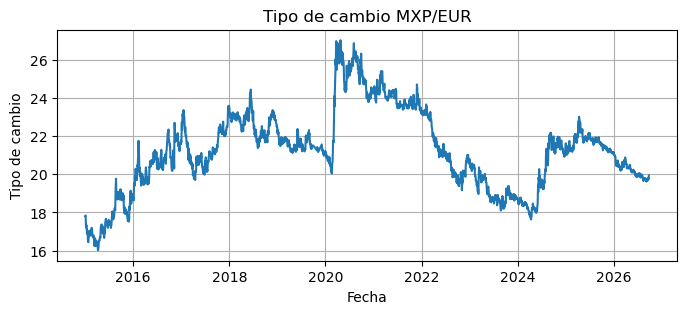

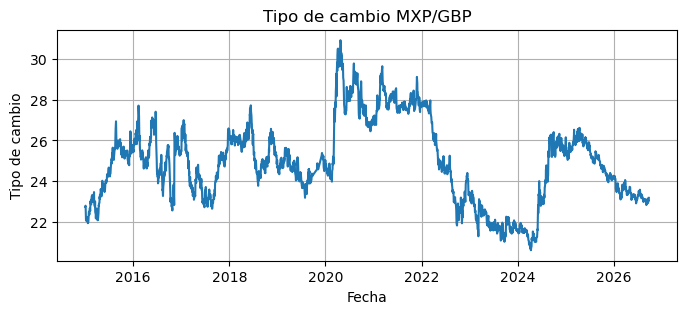

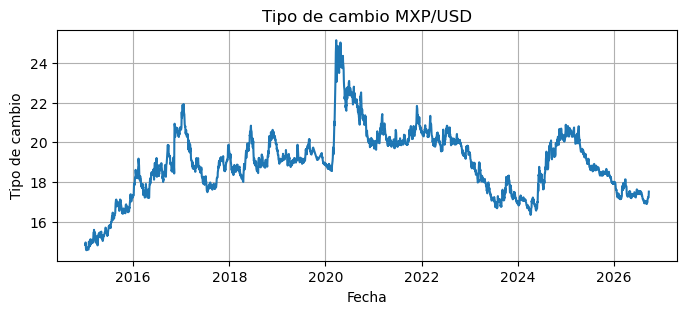

In [24]:
#Observamos en gráfica la evolución de tc

for divisa in TC["tmb_MonedaOrig"].unique():
    datos = TC[TC["tmb_MonedaOrig"] == divisa]
    plt.figure(figsize=(8, 3))
    plt.plot(datos["tmb_FechaCarga"], datos["tmb_PrecioLimpio"])
    plt.title(f"Tipo de cambio MXP/{divisa}")
    plt.xlabel("Fecha")
    plt.ylabel("Tipo de cambio")
    plt.grid(True)
    plt.show()

Podemos observar que tienen varios periodos similares, se presentan cambios importantes en 2020, muestran una caída posteriormente y una recuperación hasta 2024-2025 y por último muestran una tendencia descendente.

In [42]:
# Calculamos el rendimiento diario

TC = TC.sort_values(["tmb_MonedaOrig", "tmb_FechaCarga"])
TC["Rendimiento"] = (TC.groupby("tmb_MonedaOrig")["tmb_PrecioLimpio"].pct_change())

 #Eliminamos los primeros datos ya que no contienen información
TC = TC[3:]

**Cálculo de rendimiento diario**

El cálculo del rendimiento se realizó mediante la siguiente formúla:

$$
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
$$

donde $P_t$ representa el tipo de cambio en el día $t$.

La primera observación de cada serie no cuenta con un valor previo para realizar el cálculo, por lo que se eliminaron.

In [43]:
# Revisamos el comportamiento de los rendimientos

TC.groupby("tmb_MonedaOrig")["Rendimiento"].describe()

,count,mean,std,min,25%,50%,75%,max
tmb_MonedaOrig,,,,,,,,
EUR,2901.0,0.000069,0.007826,-0.030174,-0.004359,-0.000248,0.004009,0.075531
GBP,2903.0,0.000036,0.007868,-0.043231,-0.004436,-0.000263,0.004248,0.087721
USD,2903.0,0.000082,0.007697,-0.038826,-0.004226,-0.000244,0.004108,0.084833


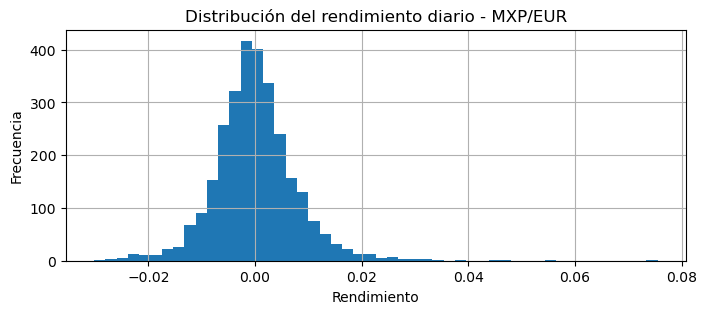

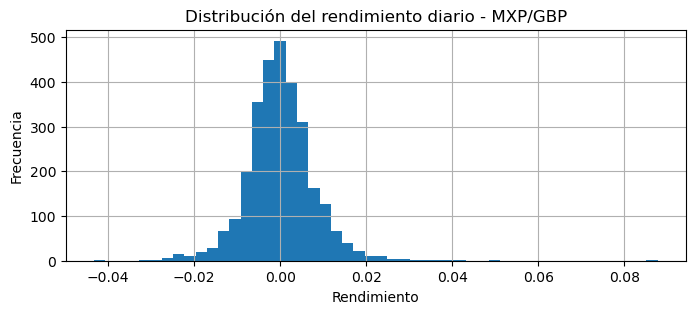

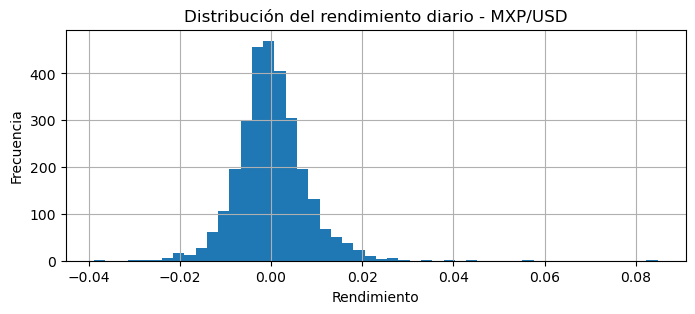

In [44]:
# Graficamos el comportamiento de cada una de las divisas

for divisa in TC["tmb_MonedaOrig"].unique():
    datos = TC[TC["tmb_MonedaOrig"] == divisa]
    plt.figure(figsize=(8, 3))
    plt.hist(datos["Rendimiento"], bins=50)
    plt.title(f"Distribución del rendimiento diario - MXP/{divisa}")
    plt.xlabel("Rendimiento")
    plt.ylabel("Frecuencia")
    plt.grid(True)
    plt.show()

**Distribución de los rendimientos diarios**

Los histogramas muestran que los rendimientos diarios de las tres divisas se concentran alrededor de cero, se observa una dispersión relativamente pequeña en la mayor parte de las observaciones; esto indica la existencia de algunas variaciones diarias de mayor magnitud.

Los estadísticos descriptivos muestran desviaciones estándar cercanas a $0.008$ para los cruces de USD y GBP, para EUR cercanas a $0.006$, mientras que las medias se encuentran muy próximas a cero. Esto sugiere que el comportamiento del tipo de cambio presenta periodos de variación estables junto con episodios de movimientos diarios más pronunciados.

Los valores extremos no se eliminarán automáticamente, ya que podrían corresponder a movimientos reales del mercado y posteriormente podrán
ser analizados como parte del comportamiento de las series.

In [48]:
# Calculamos la volatilidad de 20 días 

TC["Vola20"] = (TC.groupby("tmb_MonedaOrig")["Rendimiento"].transform(lambda x: x.rolling(20).std()))

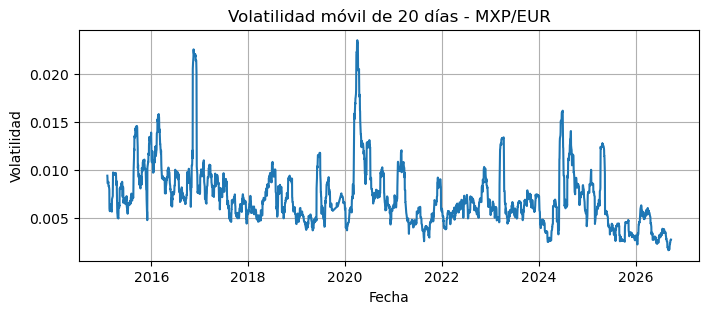

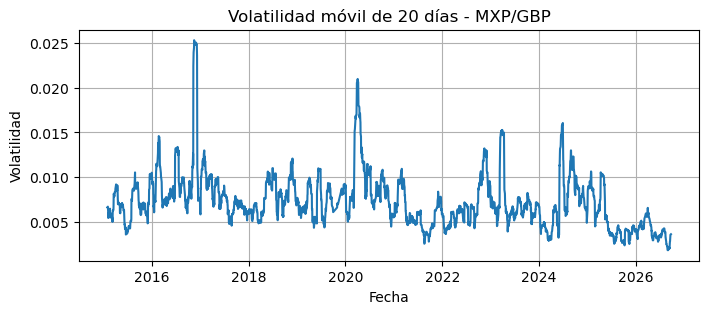

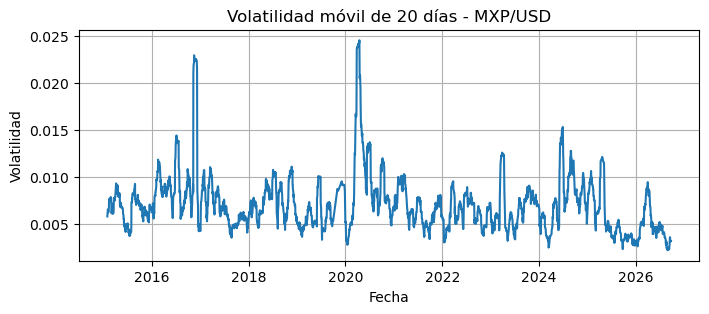

In [51]:
# Graficamos la volatilidad

for divisa in TC["tmb_MonedaOrig"].unique():
    datos = TC[TC["tmb_MonedaOrig"] == divisa]
    plt.figure(figsize=(8, 3))
    plt.plot(datos["tmb_FechaCarga"], datos["Vola20"])
    plt.title(f"Volatilidad móvil de 20 días - MXP/{divisa}")
    plt.xlabel("Fecha")
    plt.ylabel("Volatilidad")
    plt.grid(True)
    plt.show()

**Volatilidad**

Para poder analizar el tipo de cambio a lo largo del tiempo se calculo la volatilidad móvil de 20 días utilizando la desviación estándar de los rendimientos.

$$
\sigma_{t,20} =
\sqrt{
\frac{1}{19}
\sum_{i=0}^{19}
(R_{t-i}-\bar{R}_{t,20})^2
}
$$

donde $R_t$ representa el rendimiento diario y $\bar{R}_{t,20}$ es el
rendimiento promedio de los últimos 20 días hábiles.

Las gráficas muestran que la volatilidad cambia a lo largo del tiempo y se observan incrementos de volatilidad que aparecen de manera similar entre las tres divisas.

Esta variable será utilizada posteriormente como una característica (*feature*) para el análisis y modelos predictivos.

In [52]:
# Calcularemos la correlación de las divisas entre sus rendimientos

TC.pivot(index="tmb_FechaCarga", columns="tmb_MonedaOrig", values="Rendimiento").corr()

tmb_MonedaOrig,EUR,GBP,USD
tmb_MonedaOrig,,,
EUR,1.000000,0.821069,0.795189
GBP,0.821069,1.000000,0.715368
USD,0.795189,0.715368,1.000000


**Correlación entre divisas**

Para analizar la relación entre los movimientos diarios de las divisas se calculó la matriz de correlación de los rendimientos.

Observando los resultados, las tres relaciones presentan una correlación positiva, lo que indica que los rendimientos tienden a presentar movimientos en la misma dirección. La correlación más alta se observa entre *EUR* y *GBP*, la menor se presenta entre *GBP* y *USD*.

La correlación representa una asociación lineal y no implica causalidad, estos resultados pueden ser utilizados posteriormente para evaluar si los movimientos de otras monedas aportan información útil como variables predictoras.